In [ ]:
!pip install -q wandb lightning

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = "trungvit"
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

trungvit_chromosome_path = kagglehub.dataset_download('trungvit/chromosome')

print('Data source import complete.')


Data source import complete.


#Visualize some data point

In [ ]:
trungvit_chromosome_path

'/root/.cache/kagglehub/datasets/trungvit/chromosome/versions/1'

In [ ]:
from torchvision import datasets, transforms

TRAIN_PATH = trungvit_chromosome_path + '/train_data/final/single_chromosome'
TEST_PATH = trungvit_chromosome_path + '/test_data/single_chromosome'



train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=transforms.ToTensor())
test_dataset = datasets.ImageFolder(TEST_PATH, transform=transforms.ToTensor())


In [ ]:
train_dataset[0]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 0)

In [ ]:
# visualize image
import matplotlib.pyplot as plt

def show_image(data_point):

  image, label = data_point
  plt.figure(figsize = (10, 6))
  plt.title(f"Label is {label}")
  plt.imshow(image.permute(1, 2, 0))
  plt.show()



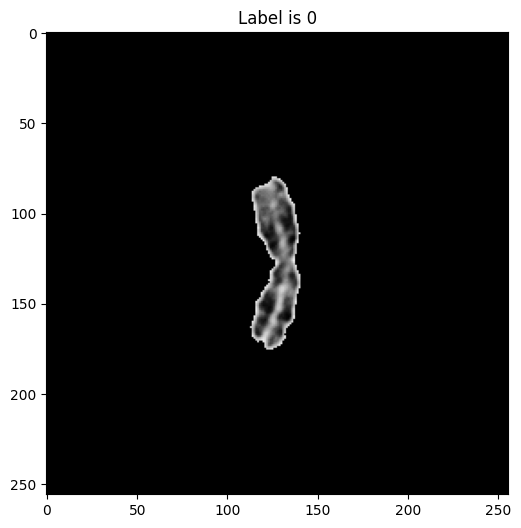

In [ ]:
show_image(train_dataset[0])

In [ ]:
labels = train_dataset.classes

num_labels = set(labels)

print(num_labels)

{'23', '16', '10', '2', '20', '18', '8', '5', '12', '3', '4', '24', '6', '15', '11', '9', '17', '14', '13', '1', '21', '22', '7', '19'}


In [ ]:
train_dataset[0][0].shape

torch.Size([3, 256, 256])

In [ ]:
len(num_labels)

24

# Training

In [ ]:
from torchvision import models
from torchsummary import summary

model = models.resnet18(pretrained=True).cuda()

summary(model, (3, 256, 256))

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]           9,408
       BatchNorm2d-2         [-1, 64, 128, 128]             128
              ReLU-3         [-1, 64, 128, 128]               0
         MaxPool2d-4           [-1, 64, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]          36,864
       BatchNorm2d-6           [-1, 64, 64, 64]             128
              ReLU-7           [-1, 64, 64, 64]               0
            Conv2d-8           [-1, 64, 64, 64]          36,864
       BatchNorm2d-9           [-1, 64, 64, 64]             128
             ReLU-10           [-1, 64, 64, 64]               0
       BasicBlock-11           [-1, 64, 64, 64]               0
           Conv2d-12           [-1, 64, 64, 64]          36,864
      BatchNorm2d-13           [-1, 64, 64, 64]             128
             ReLU-14           [-1, 64,

In [ ]:
import lightning as pl
from torch.utils.data import random_split, DataLoader


class ChromosomeDataModule(pl.LightningDataModule):

  def __init__(self, base_path: str, train_dir: str, test_dir,
               val_train_ratio: float = 0.1, batch_size: int = 32, transform = None):
    super().__init__()
    self.base_path = base_path
    self.train_dir = train_dir
    self.test_dir = test_dir
    self.val_train_ratio = val_train_ratio

    self.batch_size = batch_size



  def preprare_data(self):
    self.base_path =  kagglehub.dataset_download('trungvit/chromosome')


  def setup(self, stage: str):

    if stage ==  'fit':
      train_path = self.base_path + self.train_dir
      train_dataset = datasets.ImageFolder(train_path, transform=transforms.ToTensor())

      train_size = int(len(train_dataset) * (1 - self.val_train_ratio))
      val_size = len(train_dataset) - train_size

      self.train_dataset, self.val_dataset = random_split(train_dataset, [train_size, val_size])
    elif stage == 'test':
      test_path = self.base_path + self.test_dir
      self.test_dataset = datasets.ImageFolder(test_path, transform=transforms.ToTensor())
    else :
      test_path = self.base_path + self.test_dir
      self.data_predict = datasets.ImageFolder(test_path,  transform = transforms.ToTensor())




  def train_dataloader(self):
    return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers= 4)


  def val_dataloader(self):
    return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers= 4)


  def test_dataloader(self):
    return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers= 4)



In [ ]:
from re import X
import torch.nn as nn
from torchmetrics import Accuracy, Precision, Recall, F1Score
import torch.optim as optim
import timm


class ResnetLightningModule(pl.LightningModule):

  def __init__(self, num_classes = 24, model_name = "efficientnet_b0" ):
    super().__init__()
    self.model = models.resnet18(pretrained=True)
    # for param in self.model.parameters():
    #     param.requires_grad = False


    in_features = self.model.fc.in_features
    self.model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    self.criterion = nn.CrossEntropyLoss()

    self.train_acc = Accuracy(task = 'multiclass', num_classes = num_classes)
    self.val_acc = Accuracy(task = 'multiclass', num_classes = num_classes)
    self.test_acc = Accuracy(task = 'multiclass', num_classes = num_classes)

    self.val_precision = Precision(task = 'multiclass', num_classes = num_classes)
    self.val_recall = Recall(task = 'multiclass', num_classes = num_classes)
    self.val_f1 = F1Score(task = 'multiclass', num_classes = num_classes)

    self.test_precision = Precision(task = 'multiclass', num_classes = num_classes)
    self.test_recall = Recall(task = 'multiclass', num_classes = num_classes)
    self.test_f1 = F1Score(task = 'multiclass', num_classes = num_classes)


    self.save_hyperparameters()



  def forward(self, x):
    output = self.model(x)
    return output



  def training_step(self, batch, batch_idx):

    x, y = batch

    outputs = self.model(x)
    loss = self.criterion(outputs, y)

    self.train_acc(outputs, y)
    self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
    self.log('train_acc', self.train_acc, on_step=False, on_epoch=True, prog_bar=True, logger=True)

    return loss



  def validation_step(self, batch, batch_idx):
    x, y = batch

    outputs = self.model(x)
    loss = self.criterion(outputs, y)

    self.val_acc(outputs, y)
    self.val_precision(outputs, y)
    self.val_recall(outputs, y)
    self.val_f1(outputs, y)

    self.log('val_loss', loss, prog_bar=True)
    self.log('val_acc', self.val_acc, prog_bar=True)
    self.log('val_precision', self.val_precision, prog_bar=True)
    self.log('val_recall', self.val_recall, prog_bar=True)



  def test_step(self, batch, batch_idx):
    x, y = batch

    outputs = self.model(x)

    self.test_acc(outputs, y)
    self.test_precision(outputs, y)
    self.test_recall(outputs, y)
    self.test_f1(outputs, y)

    self.log('test_acc', self.test_acc, prog_bar=True)
    self.log('test_precision', self.test_precision, prog_bar=True)
    self.log('test_recall', self.test_recall, prog_bar=True)
    self.log('test_f1', self.test_f1, prog_bar=True)


  def configure_optimizers(self) :
    optimizer = optim.AdamW(self.parameters(), lr=1e-4, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    return {
        'optimizer': optimizer,
        'lr_scheduler': {
            'scheduler': scheduler,
            'monitor': 'val_acc',
            'interval': 'epoch',
            'frequency': 1
        }
    }








In [ ]:
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
import wandb


wandb.login(
  key =  userdata.get('WANDB')
)


wandb_logger = WandbLogger(
      name = "resnet18-transfer-learning",
      project = "chromosome-classification",
      log_model = True

)

model_checkpoint = ModelCheckpoint(
      dirpath='my/path',
      filename='{epoch}-{val_loss:.2f}',
      monitor='val_loss',
      save_top_k=3,
      mode='min',
      save_weights_only=True
)

early_stopping = EarlyStopping(
      monitor='val_loss',
      patience=3,
      verbose=False,
      mode='min'
)




trainer = pl.Trainer(
    accelerator = "cuda" ,
    devices = 1,
    max_epochs= 20,
    callbacks = [early_stopping, model_checkpoint],
    logger = wandb_logger,
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: theseventeengv (trungviet17) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [ ]:
BASE_PATH = trungvit_chromosome_path
TRAIN_DIR = '/train_data/final/single_chromosome'
TEST_DIR = '/test_data/single_chromosome'


model = ResnetLightningModule()
datamodule = ChromosomeDataModule(base_path= BASE_PATH, train_dir= TRAIN_DIR, test_dir = TEST_DIR)

trainer.fit(model, datamodule)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


/usr/local/lib/python3.11/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /content/my/path exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name           | Type                | Params | Mode 
----------------------------------------------------------------
0  | model          | ResNet              | 11.3 M | train
1  | criterion      | CrossEntropyLoss    | 0      | train
2  | train_acc      | MulticlassAccuracy  | 0      | train
3  | val_acc        | MulticlassAccuracy  | 0      | train
4  | test_acc       | MulticlassAccuracy  | 0      | train
5  | val_precision  | MulticlassPrecision | 0      | train
6  | val_recall     | MulticlassRecall    | 0      | train
7  | val_f1         | MulticlassF1Score   | 0      | train
8  | test_precision | MulticlassPrecision | 0      | train
9  | test_recall    | MulticlassRecall    | 0      

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
trainer.test(model, datamodule)


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9250267744064331     │
│          test_f1          │    0.9250267744064331     │
│      test_precision       │    0.9250267744064331     │
│        test_recall        │    0.9250267744064331     │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.9250267744064331,
  'test_precision': 0.9250267744064331,
  'test_recall': 0.9250267744064331,
  'test_f1': 0.9250267744064331}]